# P4 - Final Assignment
## SEA4001W: Intro to Data Science (Prof Marcello Vichi)¶
### Vivienne Banks - BNKVIV001
#### 23 March 2026
---

In [1]:
# Import the necessary packages

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LogNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmocean
import calendar

# Remove runtime warnings (Mac has a lot of these).
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


### 1. A large figure with the map of the region bathymetry, using an adequate colormap

In [2]:
# Load the bathymetry data
bathymetry_ds = xr.open_dataset("GMRTv4_4_1_20260323topo.grd") 
bathymetry_ds

<xarray.Dataset> Size: 24MB
Dimensions:    (side: 2, xysize: 3059138)
Dimensions without coordinates: side, xysize
Data variables:
    x_range    (side) float64 16B ...
    y_range    (side) float64 16B ...
    z_range    (side) float64 16B ...
    spacing    (side) float64 16B ...
    dimension  (side) int32 8B ...
    z          (xysize) float64 24MB ...
Attributes:
    title:    GMRT Grid
    source:   \n\tProjection: Cylindrical Equidistant\n\tCreated with GMRT Ma...

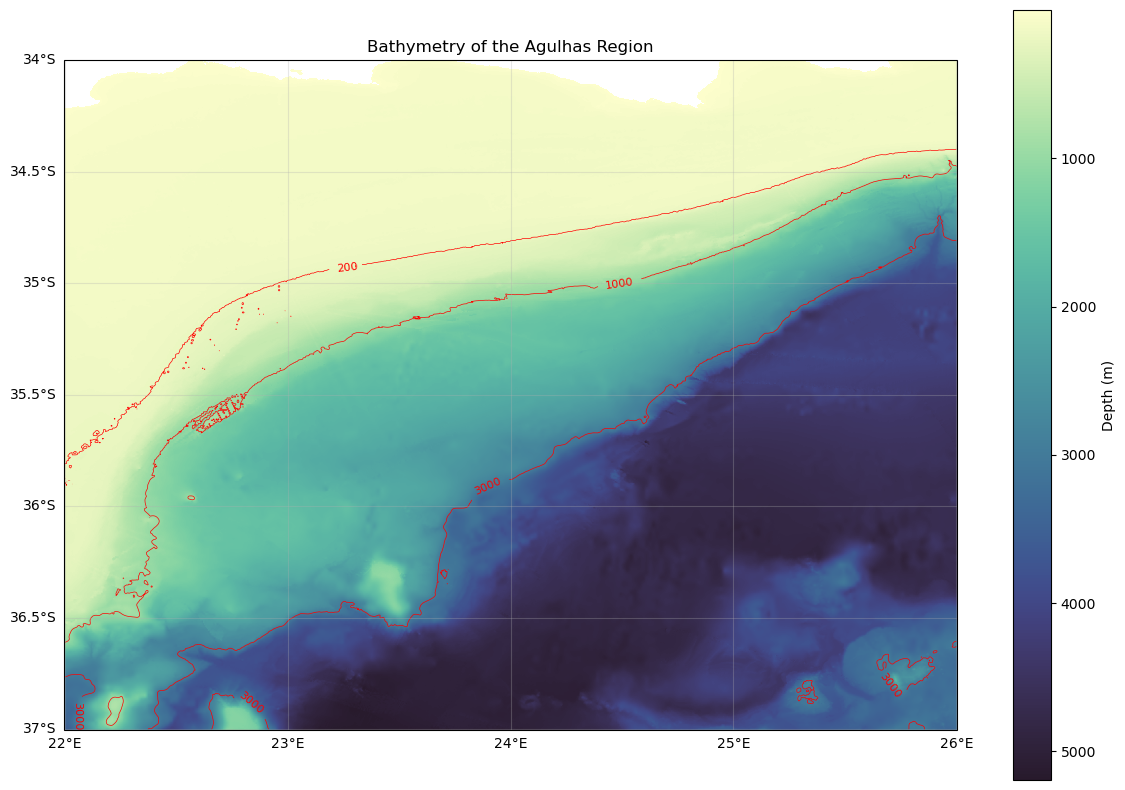

In [3]:
# ----------------------------------
# Extract variables from the dataset
# ----------------------------------

# Grid values
x_range = bathymetry_ds['x_range'].values  # [min_lon, max_lon]
y_range = bathymetry_ds['y_range'].values  # [min_lat, max_lat]

spacing = bathymetry_ds['spacing'].values  # grid spacing (distance between points/nodes)
dimension = bathymetry_ds['dimension'].values  # [nx, ny]
nx, ny = dimension # Number of points/nodes in the x and y directions

lon = np.linspace(x_range[0], x_range[1], nx) # longitude array
lat = np.linspace(y_range[0], y_range[1], ny) # latitude array

# Depth values
z = bathymetry_ds['z'].values # depth values (1D array)
depth = z.reshape((ny, nx)) # Reshape the 1D depth array into a 2D grid (lat, lon)
depth = np.flipud(depth) # Flip the array in the vertical direction so that latitude increases correctly
depth_pos = -depth # Convert depth to positive values for plotting
depth_ocean = np.where(depth_pos > 0, depth_pos, np.nan) # Exclude invalid depth values

# ----------------------------------
# Plot the figure
# ----------------------------------

# Create the figure with a projection from cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree()) 

# Plot depth values against longitude and latitude with a colormap
c = ax.pcolormesh(lon, lat, depth_ocean, cmap=cmocean.cm.deep, shading='auto')

# Colour bar
cb = plt.colorbar(c)
cb.set_label('Depth (m)')
cb.ax.invert_yaxis() # Invert the y axis so shallower values are at the top

# Contours
contour_levels = [200, 1000, 3000,] # These levels highlight the Agulhas Bank bathymetry
contours = ax.contour(lon, lat, depth_pos, levels = contour_levels, colors='red', linewidths=0.5)
ax.clabel(contours, inline=True, fontsize=8)

# Grid lines
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Title
plt.title('Bathymetry of the Agulhas Region')

# Layout
plt.tight_layout()

# Save and show figure
plt.savefig("bathymetry_map.png", dpi=300)
plt.show()

---


### 2. A map of the mean annual chlorophyll. 
Choose carefully the range of values and the colormap, to display the different regions 
(Note: chlorophyll is usually plotted in logarithmic scale, but this is not a requirement)

In [4]:
# Load the chlorophyll data
chl_ds = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc") 
chl_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

#### Subsetting the Agulhas region for the chlorophyll plots

In [5]:
# Extract chlorophyll data
chl = chl_ds['chlor_a']

# Get the coordinates from the bathymetry grid 
lon_min, lon_max = bathymetry_ds['x_range'].values
lat_min, lat_max = bathymetry_ds['y_range'].values

# Subset the Aghulas Region
chl_region = chl.sel(lon=slice(lon_min, lon_max), lat=slice(lat_max, lat_min))


#### Calculating and plotting the mean chlorophyll concentration

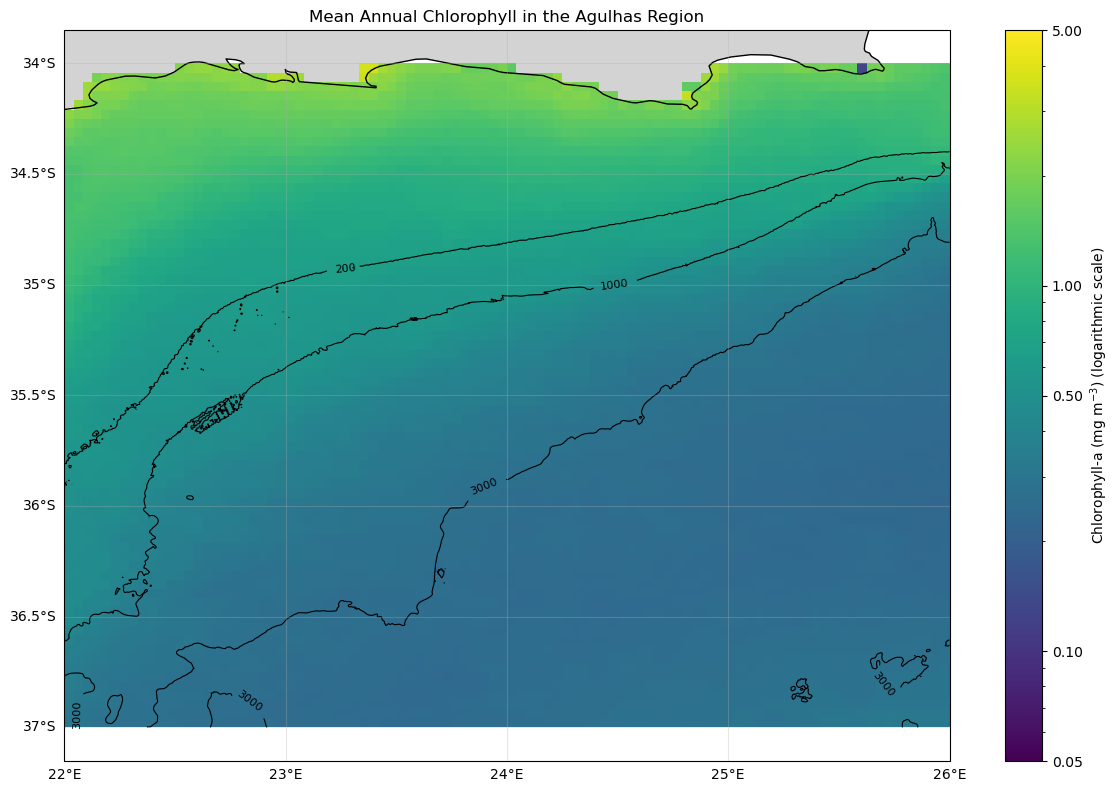

In [6]:
# ----------------------------------
# Calculate the mean
# ----------------------------------
chl_mean = chl_region.mean(dim='time') # Average data along the time dimension
chl_plot = chl_mean.where(np.isfinite(chl_mean)) # Exclude invlaid data points for the plot


# ----------------------------------
# Plot the figure
# ----------------------------------

# Plot mean annual chlorophyll data with a projection from cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree()) 

# Plot the chlorophyll mean data on the logarithmic scale against latitude and longitude of the Agulhas region. 
c = plt.pcolormesh(chl_mean['lon'], chl_mean['lat'], chl_plot, cmap='viridis', norm=LogNorm(vmin=0.05, vmax=5), shading='auto', transform=ccrs.PlateCarree())

# Colour bar with correct tick labels
cb = plt.colorbar(c)
cb.set_label('Chlorophyll-a (mg m$^{-3}$) (logarithmic scale)')
cb.formatter = ScalarFormatter() 
cb.update_ticks()
cb.set_ticks([0.05, 0.1, 0.5, 1, 5])

# Bathymetry Contours (uses data variables from bathymetry plot above)
cs = ax.contour(lon, lat, depth_pos, levels=contour_levels , colors='black', linewidths=0.8, transform=ccrs.PlateCarree())
ax.clabel(cs, fontsize=8)

# Coastline and Land
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Grid lines
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Title
plt.title('Mean Annual Chlorophyll in the Agulhas Region')

# Layout
plt.tight_layout()

# Save and show figure
plt.savefig("chlorophyll_annual_mean.png", dpi=300)
plt.show()

---

 ### 3. A faceted figure, showing 12 maps, one for each month. 
 
 The colorbar range can be different from the annual mean map, because it should show the seasonal variation.

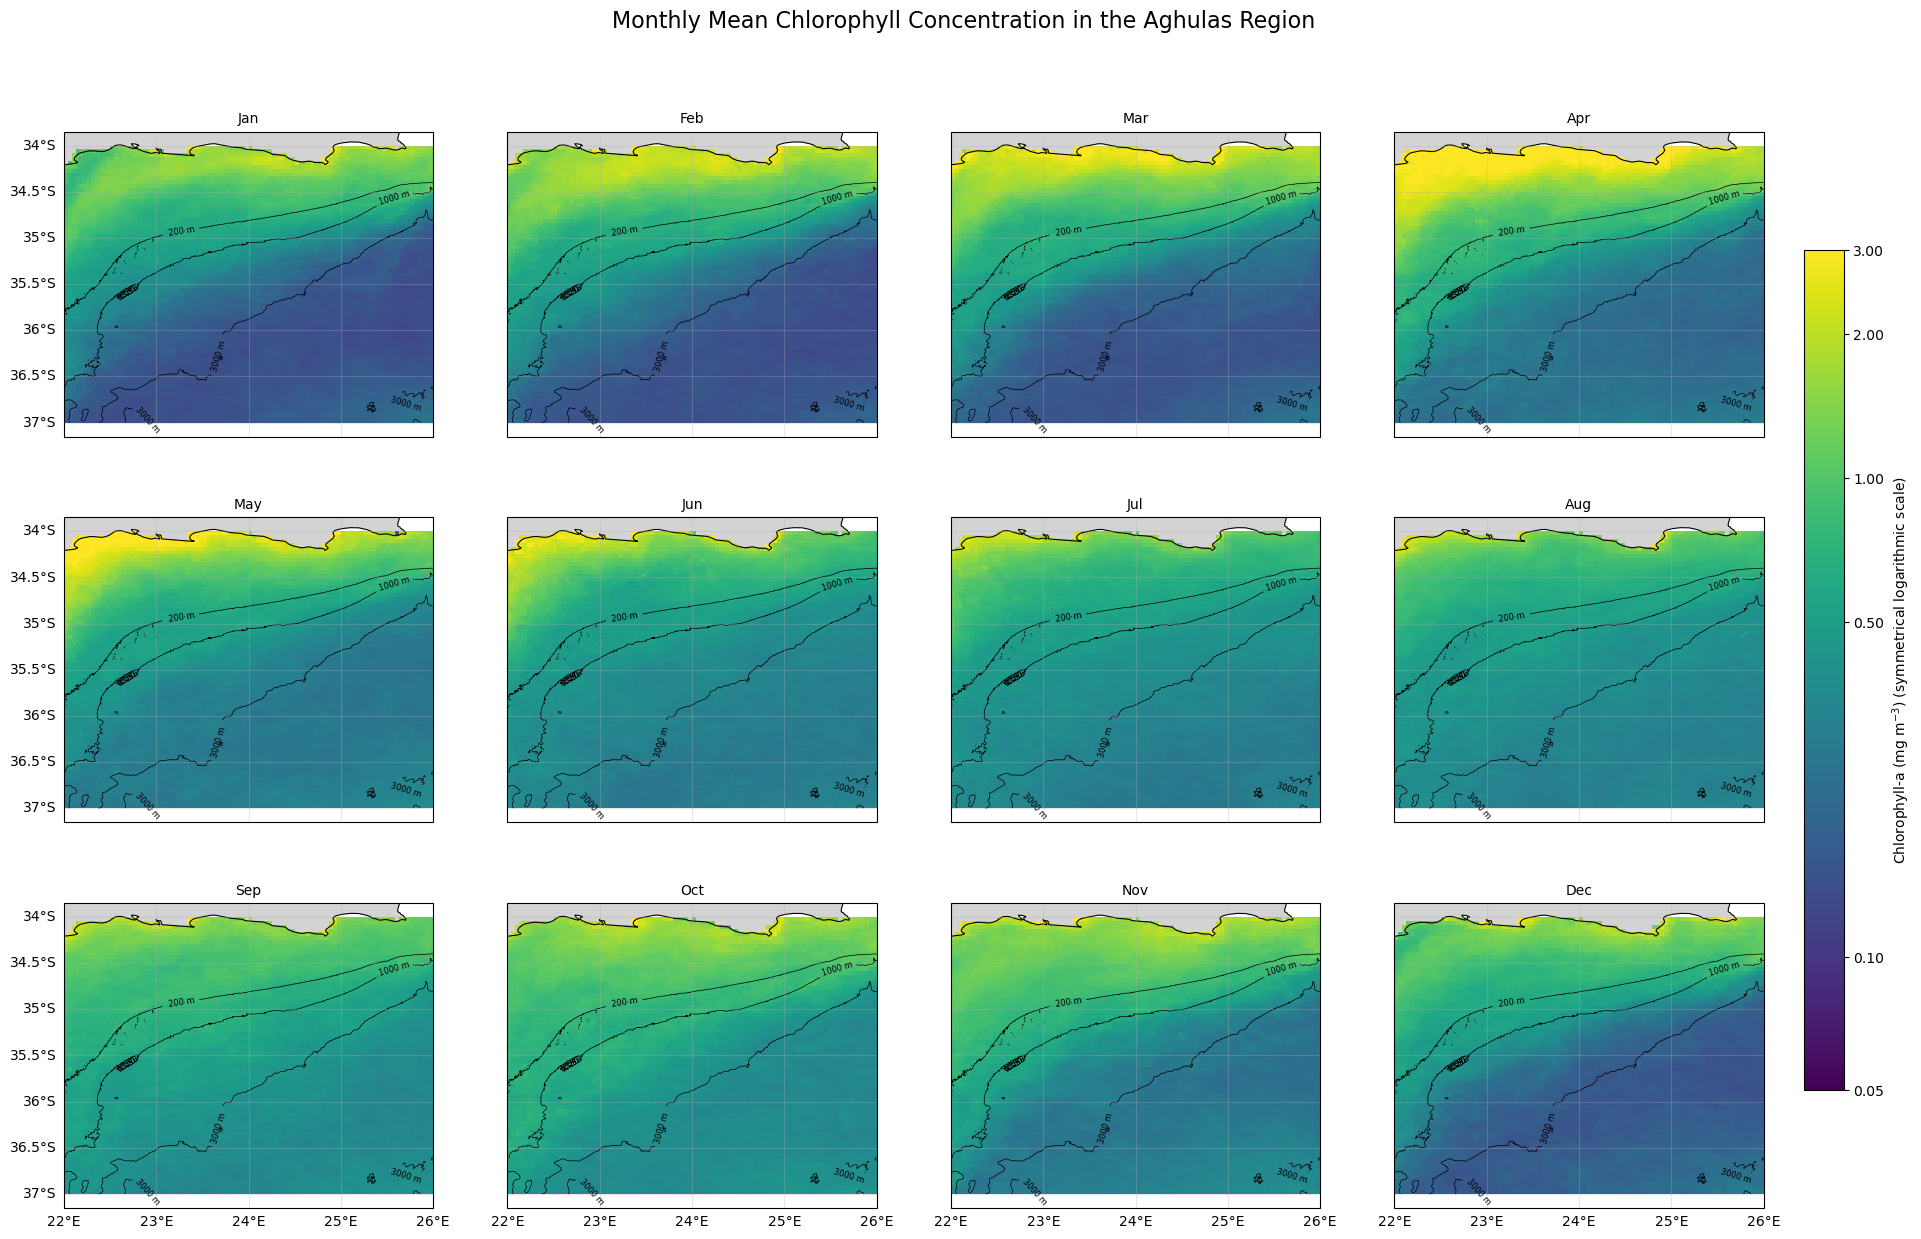

In [7]:
# ----------------------------------
# Prepare variables
# ----------------------------------

# Bathymetry and chlorophyll data should already be loaded

# Subset the Agulhas Region
chl_region = chl.sel(lon=slice(lon_min, lon_max), lat=slice(lat_max, lat_min))

# Set up the month range and names
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


# ----------------------------------
# Plot the figures
# ----------------------------------

# Prepare figure: 12 subplots (3 rows x 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})


# Loop through the months and plot the monthly mean chlorophyll
for i, month in enumerate(months):
    ax = axes.flat[i] # Set the axis for the month
    
    # Select month and average across years 
    chl_month = chl_region.sel(time=chl_region['time'].dt.month == month).mean(dim='time')
    
    # Exclude invlaid data points for the plot
    chl_plot = chl_month.where(np.isfinite(chl_month))
    
    # Plot the chlorophyll mean data on the symmetric logarithmic scale against latitude and longitude of the Agulhas region. 
    pcm = ax.pcolormesh(chl_month['lon'], chl_month['lat'], chl_plot, cmap='viridis', shading='auto', norm=SymLogNorm(linthresh=0.1, linscale=0.5, vmin=0.05, vmax=3), transform=ccrs.PlateCarree())
    # uses SymLogNorm ("symmetric log" scale) to visulise values closer to 0 more easily
    
    # Bathymetry contours
    cs = ax.contour(lon, lat, depth_pos, levels = contour_levels, colors='black', linewidths=0.5, transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt='%d m', fontsize=6)
    
    # Coastline and land
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    
    # Title for each subplot
    ax.set_title(month_names[i], fontsize=10)



# Grid lines
nrows, ncols = 3, 4
for i, ax in enumerate(axes.flat):
    row = i // ncols
    col = i % ncols
    
    gl = ax.gridlines(draw_labels=True, alpha=0.3)

    # Turn off all labels first
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.bottom_labels = False

    # Only left column gets latitude labels
    if col == 0:
        gl.left_labels = True

    # Only bottom row gets longitude labels
    if row == nrows - 1:
        gl.bottom_labels = True


# Colour bar with correct tick labels
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = plt.colorbar(pcm, cax=cbar_ax)
cb.set_label('Chlorophyll-a (mg m$^{-3}$) (symmetrical logarithmic scale)')
cb.formatter = ScalarFormatter()
cb.update_ticks()
cb.set_ticks([0.05, 0.1, 0.5, 1, 2, 3])

# Main Title
plt.suptitle('Monthly Mean Chlorophyll Concentration in the Aghulas Region', fontsize=16, y=1.05)

# Layout
fig.subplots_adjust(left=0.05, right=0.9, top=0.95, bottom=0.05, wspace=0.2, hspace=0.25)

# Save and show figure
plt.savefig("chlorophyll_monthly_maps.png", dpi=300)
plt.show()

---

### 4. Timeseries Plot

A timeseries plot showing two lines: the mean seasonal cycle of the whole region compared with the timeseries from a single grid point of your choice, preferably close to an area of high chlorophyll (use the keyword method='nearest' to select the point)


In [8]:
# ----------------------------------
# Select the point with the highest mean chlorophyll
# ----------------------------------
max_idx = chl_mean.argmax(dim=['lat', 'lon']) # Index the point with the highest mean chlorophyll value

point_lat = chl_mean['lat'][max_idx['lat']].values # Extract the latitude 
point_lon = chl_mean['lon'][max_idx['lon']].values # Extract the longitude 

print(point_lat, point_lon)

-34.02083333333333 23.354166666666657


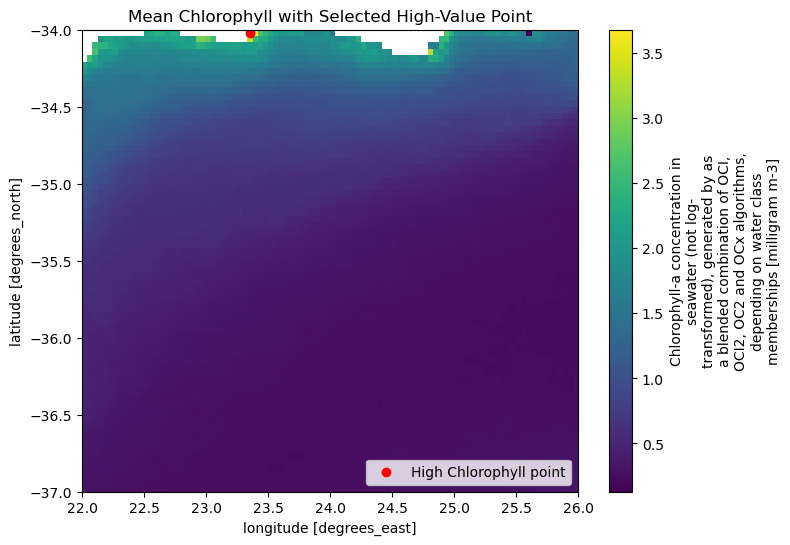

In [9]:
# ----------------------------------
# Plot the location of the high chlorophyll point - for interests sake
# ----------------------------------

# Plot mean chlorophyll
plt.figure(figsize=(8,6))
chl_mean.plot() # Uses default settings and does not log transform chlorophyll values

# Add the selected point
plt.scatter(point_lon, point_lat, color='red', label='High Chlorophyll point') 

# Legend
plt.legend(loc = 'lower right') 

 # Title
plt.title('Mean Chlorophyll with Selected High-Value Point')

# Show the plot
plt.show()

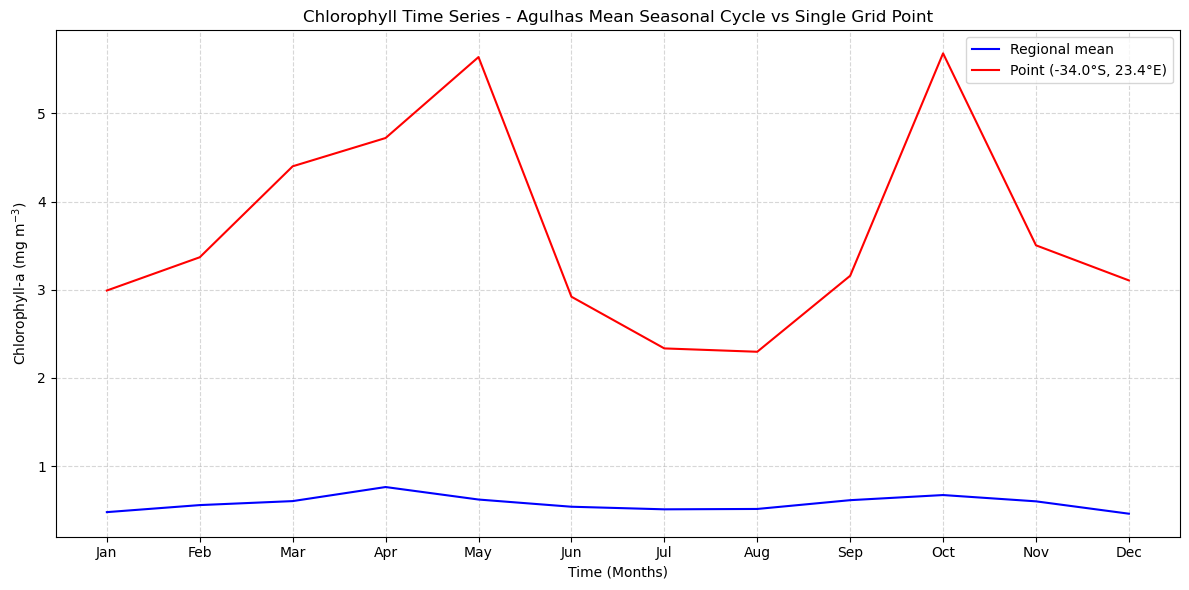

In [10]:
# ----------------------------------
# Calculate the mean seasonal cycles
# ----------------------------------

# Calculate the Agulhas region mean time series (average over space dimensions)
chl_region_mean = chl_region.mean(dim=['lat', 'lon']).groupby('time.month').mean()

# Calculate the point time series (average over space dimensions)
chl_point = chl_region.sel(lat=point_lat, lon=point_lon, method='nearest').groupby('time.month').mean()

# ----------------------------------
# Plot the figure
# ----------------------------------

plt.figure(figsize=(12, 6))

# Plot the Agulhas regions mean time series
plt.plot(chl_region_mean['month'], chl_region_mean, label='Regional mean', color='blue')

# Plot the single grid point time series
plt.plot(chl_point['month'], chl_point, label=f'Point ({point_lat:.1f}°S, {point_lon:.1f}°E)', color='red')

# Axis Labels
months = [calendar.month_abbr[m] for m in chl_region_mean['month'].values] # Make the x-axis labels the months
plt.xticks(chl_region_mean['month'], months)
plt.xlabel('Time (Months)')
plt.ylabel('Chlorophyll-a (mg m$^{-3}$)')

# Title and Legend
plt.title('Chlorophyll Time Series - Agulhas Mean Seasonal Cycle vs Single Grid Point')
plt.legend()

# Gridlines
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()

# Save and show the figure
plt.savefig("chlorophyll_timeseries.png", dpi=300)
plt.show()

---

## References

Ryan, W.B.F., S.M. Carbotte, J.O. Coplan, S. O'Hara, A. Melkonian, R. Arko, R.A. Weissel, V. Ferrini, A. Goodwillie, F. Nitsche, J. Bonczkowski, and R. Zemsky (2009), Global Multi-Resolution Topography synthesis, Geochem. Geophys. Geosyst., 10, Q03014, doi: 10.1029/2008GC002332


Valente, A, Sathyendranath, S, Brotas, V, Groom, S, Grant, M, Taberner, M, Antoine, D, Arnone, R, Balch, W, Barker, K, Barlow, R, Bélanger, S, Berthon, JF, Besiktepe, S, Brando, V, Canuti, E, Chavez, F, Claustre, H, Crout, R, Frouin, R, Garcìa-Soto, C, Gibb, SW, Gould, R, Hooker, S, Kahru, M, Klein, H, Kratzer, S, Loisel, H, McKee, D, Mitchell, BG, Moisan, T, Muller-Karger, F., O'Dowd, L, Ondrusek, M, Poulton, A, Repecaud, M, Smyth, T, Sosik, HM, Twardowski, M, Voss, K, Werdell, J, Wernand, M, Zibordi, G (2016) A compilation of global bio-optical in situ data for ocean-colour satellite applications. Earth Syst. Sci. Data, 8, 235–252, 2016 www.earth-syst-sci-data.net/8/235/2016 doi: 10.5194/essd-8-235-2016 

---